# 1. Preparacion y one hot coding

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [28]:
df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv")

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


limpieza de datos como nombres que no ayudan

In [8]:
cols_to_drop = ['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date', 'Room Number']
df_clean = df.drop(columns=cols_to_drop)

one hot, creamos colunmas Gender_Male,...

In [10]:
df_final = pd.get_dummies(df_clean, columns=['Gender', 'Blood Type', 'Medical Condition',
                                             'Insurance Provider', 'Admission Type',
                                             'Medication', 'Test Results'],
                          drop_first=True) #evitar multicolinealidad

# 2. Datos y procesos

def variable

In [11]:
X = df_final.drop('Billing Amount', axis=1)
y = df_final['Billing Amount']

division de entrenamiento

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [18]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

coeficiente, imp. de variables

In [35]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print("\n Variables que más aumentan el costo:")
print(" ")
print(coeff_df.sort_values(by='Coefficient', ascending=False).head(5))


 Variables que más aumentan el costo:
 
                            Coefficient
Blood Type_A-               1319.916611
Medical Condition_Diabetes  1100.005078
Blood Type_AB+               907.472015
Blood Type_B-                649.796433
Medication_Lipitor           412.883148


prediccion metricas

In [20]:
predictions = lm.predict(X_test)

In [34]:
print("Métricas de Errores:")
print(" ")
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print("R-squared:", round(metrics.r2_score(y_test, predictions), 4))

Métricas de Errores:
 
MAE: 12228.206299121975
RMSE: 14185.815991543386
R-squared: -0.003


# Gráficas

cobro médico

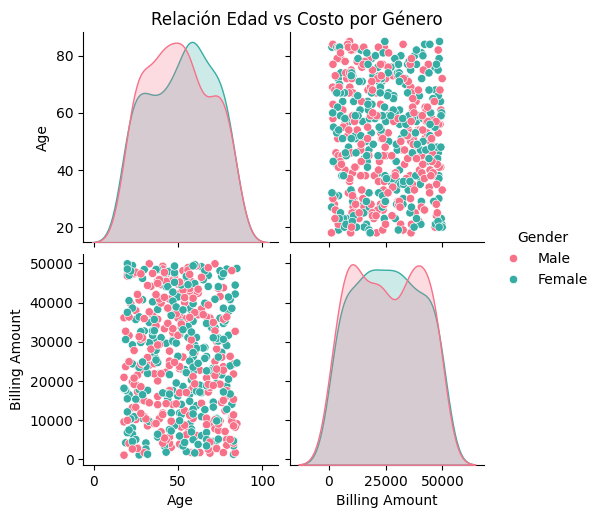

In [25]:
sns.pairplot(df.sample(500), vars=['Age', 'Billing Amount'], hue='Gender', palette='husl')
plt.suptitle('Relación Edad vs Costo por Género', y=1.02)
plt.show()

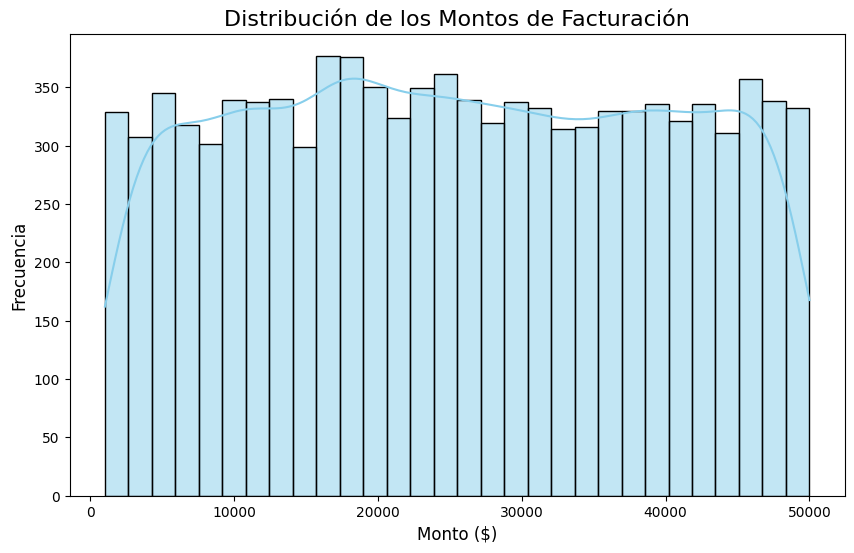

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Billing Amount'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de los Montos de Facturación', fontsize=16)
plt.xlabel('Monto ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

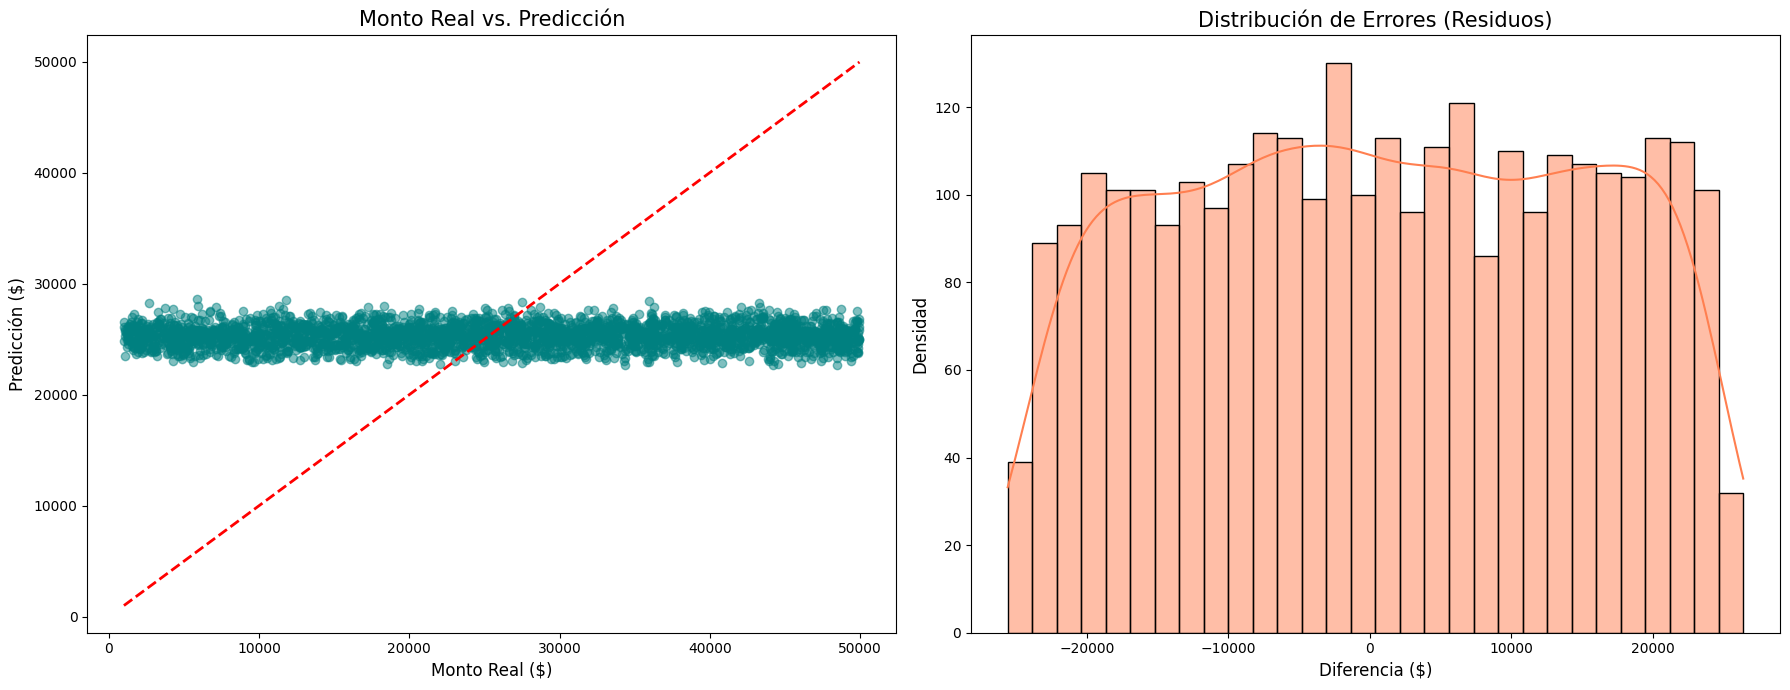

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))


ax1.scatter(y_test, predictions, alpha=0.5, color='teal')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Monto Real vs. Predicción', fontsize=15)
ax1.set_xlabel('Monto Real ($)', fontsize=12)
ax1.set_ylabel('Predicción ($)', fontsize=12)


residuos = y_test - predictions
sns.histplot(residuos, bins=30, kde=True, ax=ax2, color='coral')
ax2.set_title('Distribución de Errores (Residuos)', fontsize=15)
ax2.set_xlabel('Diferencia ($)', fontsize=12)
ax2.set_ylabel('Densidad', fontsize=12)


plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
top_corr = df_final.corr()['Billing Amount'].sort_values(ascending=False).head(10)
top_corr.plot(kind='barh', color='darkblue')
plt.title('Correlaciónes - Costo', fontsize=16)
plt.xlabel('Correlación')
plt.show()